# Clinical Trial Outcomes & Evidence Dashboard

**Python analysis notebook for the `survival::colon` randomised colon-cancer trial dataset**

This notebook performs an end-to-end portfolio analysis:

- validates the repeated-record clinical-trial structure;
- creates a one-row-per-participant analytical table;
- profiles missingness and data-quality issues;
- performs exploratory data analysis (EDA);
- estimates Kaplan–Meier curves for recurrence and overall survival endpoints;
- fits unadjusted and adjusted Cox proportional-hazards models;
- produces exploratory subgroup treatment-effect estimates; and
- exports Tableau-ready CSV files supporting the planned 12 worksheets and 3 dashboards.

> **Important:** This is an educational portfolio analysis, not medical advice. Subgroup analyses are exploratory and should not be used to make treatment decisions.

**Dataset documentation:** https://stat.ethz.ch/R-manual/R-devel/library/survival/html/colon.html  
**Study reference:** Moertel et al., *N Engl J Med* (1990), DOI: 10.1056/NEJM199002083220602

## 1. Setup and project paths

Expected project structure:

```text
clinical_trial_outcomes_evidence/
├── data/
│   └── colon.csv
├── notebooks/
│   └── clinical_trial_outcomes_evidence.ipynb
├── figures/
└── tableau_exports/
```

The path logic below works whether the notebook is launched from the project root or from the `notebooks/` folder.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
from statsmodels.duration.survfunc import SurvfuncRight
from statsmodels.duration.hazard_regression import PHReg
from statsmodels.duration.api import survdiff
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd().resolve()
if (cwd / "data" / "colon.csv").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "colon.csv").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find data/colon.csv. Put the raw file in a folder named 'data'."
    )

DATA_PATH = PROJECT_ROOT / "data" / "colon.csv"
EXPORT_DIR = PROJECT_ROOT / "tableau_exports"
FIGURE_DIR = PROJECT_ROOT / "figures"
EXPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_PATH)

Project root: /Users/tanishkshindepatil/Downloads/clinical_trial_outcomes_evidence
Raw data: /Users/tanishkshindepatil/Downloads/clinical_trial_outcomes_evidence/data/colon.csv


## 2. Load the raw data

The source dataset contains **two records per participant**: `etype=1` for recurrence and `etype=2` for death. The `status` field is the event indicator for the endpoint represented by that row.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {len(raw):,}")
print(f"Columns: {raw.shape[1]}")
print(f"Unique participants: {raw['id'].nunique():,}")
display(raw.head())

Rows: 1,858
Columns: 17
Unique participants: 929


,rownames,id,study,rx,sex,age,obstruct,perfor,adhere,nodes,status,differ,extent,surg,node4,time,etype
0,1,1,1,Lev+5FU,1,43,0,0,0,5.0000,1,2.0000,3,0,1,1521,2
1,2,1,1,Lev+5FU,1,43,0,0,0,5.0000,1,2.0000,3,0,1,968,1
2,3,2,1,Lev+5FU,1,63,0,0,0,1.0000,0,2.0000,3,0,0,3087,2
3,4,2,1,Lev+5FU,1,63,0,0,0,1.0000,0,2.0000,3,0,0,3087,1
4,5,3,1,Obs,0,71,0,0,1,7.0000,1,2.0000,2,0,1,963,2


### Data dictionary used in this notebook

- `rx`: treatment — `Obs`, `Lev`, `Lev+5FU`
- `sex`: 1 = male, 0 = female
- `obstruct`: colon obstruction by tumour
- `perfor`: colon perforation
- `adhere`: adherence to nearby organs
- `nodes`: number of positive lymph nodes
- `status`: endpoint event indicator (1 = event, 0 = censored)
- `differ`: tumour differentiation — 1 well, 2 moderate, 3 poor
- `extent`: local spread — 1 submucosa, 2 muscle, 3 serosa, 4 contiguous structures
- `surg`: surgery-to-registration timing — 0 short, 1 long
- `node4`: supplied indicator for more than four positive nodes
- `time`: days to event/censoring
- `etype`: 1 recurrence, 2 death

The official documentation notes a known inconsistency between `nodes` and `node4`. This notebook flags it but does **not** silently correct the source field.

## 3. Structural validation and raw-data quality checks

In [3]:
required_columns = {
    'id','study','rx','sex','age','obstruct','perfor','adhere','nodes','status',
    'differ','extent','surg','node4','time','etype'
}
missing_required = sorted(required_columns - set(raw.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

rows_per_id = raw.groupby('id').size()
etype_per_id = raw.groupby('id')['etype'].agg(lambda s: tuple(sorted(s.tolist())))

dq_checks = {
    'row_count': len(raw),
    'participant_count': raw['id'].nunique(),
    'duplicate_full_rows': int(raw.duplicated().sum()),
    'ids_not_two_rows': int((rows_per_id != 2).sum()),
    'ids_without_etype_1_and_2': int((etype_per_id != (1,2)).sum()),
    'invalid_status_values': int((~raw['status'].isin([0,1])).sum()),
    'invalid_etype_values': int((~raw['etype'].isin([1,2])).sum()),
    'nonpositive_time_values': int((raw['time'] <= 0).sum()),
    'invalid_sex_values': int((~raw['sex'].isin([0,1])).sum()),
    'invalid_treatment_labels': int((~raw['rx'].isin(['Obs','Lev','Lev+5FU'])).sum()),
}

# Confirm that baseline fields agree between the two endpoint records for each patient.
baseline_cols = ['study','rx','sex','age','obstruct','perfor','adhere','nodes','differ','extent','surg','node4']
baseline_mismatch = {}
for col in baseline_cols:
    n = raw.groupby('id')[col].apply(lambda s: s.nunique(dropna=False) > 1).sum()
    baseline_mismatch[col] = int(n)

dq_checks['baseline_fields_with_any_cross_record_mismatch'] = int(sum(v > 0 for v in baseline_mismatch.values()))

display(pd.DataFrame({'check': dq_checks.keys(), 'value': dq_checks.values()}))
print("Baseline mismatches by field:", baseline_mismatch)

,check,value
0,row_count,1858
1,participant_count,929
2,duplicate_full_rows,0
3,ids_not_two_rows,0
4,ids_without_etype_1_and_2,0
5,invalid_status_values,0
6,invalid_etype_values,0
7,nonpositive_time_values,0
8,invalid_sex_values,0
9,invalid_treatment_labels,0


Baseline mismatches by field: {'study': 0, 'rx': 0, 'sex': 0, 'age': 0, 'obstruct': 0, 'perfor': 0, 'adhere': 0, 'nodes': 0, 'differ': 0, 'extent': 0, 'surg': 0, 'node4': 0}


## 4. Build the one-row-per-participant analytical table

Baseline characteristics are taken from the recurrence (`etype=1`) record because the baseline fields are duplicated across the two endpoint rows. Recurrence and death outcomes are then merged into one patient-level table.

In [4]:
base_cols = ['id','study','rx','sex','age','obstruct','perfor','adhere','nodes','differ','extent','surg','node4']
base = raw.loc[raw['etype'].eq(1), base_cols].copy()

rec = (raw.loc[raw['etype'].eq(1), ['id','time','status']]
       .rename(columns={'time':'recurrence_time_days','status':'recurrence_event'}))
death = (raw.loc[raw['etype'].eq(2), ['id','time','status']]
         .rename(columns={'time':'death_time_days','status':'death_event'}))

patients = base.merge(rec, on='id', validate='one_to_one').merge(death, on='id', validate='one_to_one')

# Human-readable Tableau fields.
patients['sex_label'] = patients['sex'].map({0:'Female', 1:'Male'})
patients['obstruct_label'] = patients['obstruct'].map({0:'No', 1:'Yes'})
patients['perfor_label'] = patients['perfor'].map({0:'No', 1:'Yes'})
patients['adhere_label'] = patients['adhere'].map({0:'No', 1:'Yes'})
patients['surg_label'] = patients['surg'].map({0:'Short', 1:'Long'})
patients['differ_label'] = patients['differ'].map({1:'Well', 2:'Moderate', 3:'Poor'}).fillna('Missing')
patients['extent_label'] = patients['extent'].map({
    1:'Submucosa', 2:'Muscle', 3:'Serosa', 4:'Contiguous structures'
})
patients['age_group'] = pd.cut(
    patients['age'], bins=[-np.inf,49,64,np.inf], labels=['<50','50–64','65+']
).astype('object')
patients['nodes_group'] = pd.cut(
    patients['nodes'], bins=[-np.inf,0,4,np.inf], labels=['0','1–4','5+']
).astype('object').fillna('Missing')
patients['nodes_gt4_derived'] = np.where(patients['nodes'].notna(), (patients['nodes'] > 4).astype(int), np.nan)
patients['node4_matches_derived'] = np.where(
    patients['nodes'].notna(), patients['node4'].eq(patients['nodes_gt4_derived']), np.nan
)
patients['recurrence_status_label'] = patients['recurrence_event'].map({0:'Censored',1:'Recurrence event'})
patients['death_status_label'] = patients['death_event'].map({0:'Censored',1:'Death'})

print("Patient-level shape:", patients.shape)
display(patients.head())

Patient-level shape: (929, 30)


,id,study,rx,sex,age,obstruct,perfor,adhere,nodes,differ,extent,surg,node4,recurrence_time_days,recurrence_event,death_time_days,death_event,sex_label,obstruct_label,perfor_label,adhere_label,surg_label,differ_label,extent_label,age_group,nodes_group,nodes_gt4_derived,node4_matches_derived,recurrence_status_label,death_status_label
0,1,1,Lev+5FU,1,43,0,0,0,5.0000,2.0000,3,0,1,968,1,1521,1,Male,No,No,No,Short,Moderate,Serosa,<50,5+,1.0000,1.0000,Recurrence event,Death
1,2,1,Lev+5FU,1,63,0,0,0,1.0000,2.0000,3,0,0,3087,0,3087,0,Male,No,No,No,Short,Moderate,Serosa,50–64,1–4,0.0000,1.0000,Censored,Censored
2,3,1,Obs,0,71,0,0,1,7.0000,2.0000,2,0,1,542,1,963,1,Female,No,No,Yes,Short,Moderate,Muscle,65+,5+,1.0000,1.0000,Recurrence event,Death
3,4,1,Lev+5FU,0,66,1,0,0,6.0000,2.0000,3,1,1,245,1,293,1,Female,Yes,No,No,Long,Moderate,Serosa,65+,5+,1.0000,1.0000,Recurrence event,Death
4,5,1,Obs,1,69,0,0,0,22.0000,2.0000,3,1,1,523,1,659,1,Male,No,No,No,Long,Moderate,Serosa,65+,5+,1.0000,1.0000,Recurrence event,Death


## 5. Data-quality and completeness profile

The missing-data export is produced in long format so Tableau can filter by treatment arm and variable. The known `nodes` vs `node4` inconsistency is separately quantified.

In [5]:
profile_vars = ['age','sex','obstruct','perfor','adhere','nodes','differ','extent','surg','node4']
quality_rows = []
for arm, frame in [('Overall', patients)] + list(patients.groupby('rx', sort=False)):
    for var in profile_vars:
        missing_n = int(frame[var].isna().sum())
        quality_rows.append({
            'treatment_group': arm,
            'variable': var,
            'n_total': len(frame),
            'missing_n': missing_n,
            'missing_pct': missing_n / len(frame) if len(frame) else np.nan,
            'complete_n': int(frame[var].notna().sum()),
            'complete_pct': frame[var].notna().mean() if len(frame) else np.nan,
        })
missing_profile = pd.DataFrame(quality_rows)

node_mask = patients['nodes'].notna()
node4_mismatch_n = int((patients.loc[node_mask, 'node4'] != patients.loc[node_mask, 'nodes_gt4_derived']).sum())
node4_checked_n = int(node_mask.sum())

quality_issues = pd.DataFrame([
    {'issue':'nodes_missing', 'count':int(patients['nodes'].isna().sum()), 'denominator':len(patients),
     'pct':patients['nodes'].isna().mean(), 'note':'Missing positive-node count'},
    {'issue':'differ_missing', 'count':int(patients['differ'].isna().sum()), 'denominator':len(patients),
     'pct':patients['differ'].isna().mean(), 'note':'Missing tumour differentiation'},
    {'issue':'node4_nodes_inconsistency', 'count':node4_mismatch_n, 'denominator':node4_checked_n,
     'pct':node4_mismatch_n/node4_checked_n, 'note':'Supplied node4 differs from derived nodes > 4; retained as source-data issue'},
])

display(quality_issues)
display(missing_profile.query("missing_n > 0"))

,issue,count,denominator,pct,note
0,nodes_missing,18,929,0.0194,Missing positive-node count
1,differ_missing,23,929,0.0248,Missing tumour differentiation
2,node4_nodes_inconsistency,12,911,0.0132,Supplied node4 differs from derived nodes > 4;...


,treatment_group,variable,n_total,missing_n,missing_pct,complete_n,complete_pct
5,Overall,nodes,929,18,0.0194,911,0.9806
6,Overall,differ,929,23,0.0248,906,0.9752
15,Lev+5FU,nodes,304,9,0.0296,295,0.9704
16,Lev+5FU,differ,304,6,0.0197,298,0.9803
25,Obs,nodes,315,3,0.0095,312,0.9905
26,Obs,differ,315,7,0.0222,308,0.9778
35,Lev,nodes,310,6,0.0194,304,0.9806
36,Lev,differ,310,10,0.0323,300,0.9677


## 6. Descriptive EDA

The aim here is to understand trial-arm sizes, participant characteristics, disease burden and potential imbalance before modelling.

In [6]:
arm_summary = (patients.groupby('rx', sort=False)
    .agg(
        participants=('id','count'),
        mean_age=('age','mean'),
        median_age=('age','median'),
        male_n=('sex','sum'),
        recurrence_events=('recurrence_event','sum'),
        deaths=('death_event','sum'),
        median_nodes=('nodes','median')
    )
    .reset_index())
arm_summary['participant_pct'] = arm_summary['participants'] / len(patients)
arm_summary['male_pct'] = arm_summary['male_n'] / arm_summary['participants']
arm_summary['recurrence_event_pct'] = arm_summary['recurrence_events'] / arm_summary['participants']
arm_summary['death_pct'] = arm_summary['deaths'] / arm_summary['participants']
display(arm_summary)

,rx,participants,mean_age,median_age,male_n,recurrence_events,deaths,median_nodes,participant_pct,male_pct,recurrence_event_pct,death_pct
0,Lev+5FU,304,59.7007,62.0000,141,119,123,2.0000,0.3272,0.4638,0.3914,0.4046
1,Obs,315,59.4540,60.0000,166,177,168,2.0000,0.3391,0.5270,0.5619,0.5333
2,Lev,310,60.1129,61.0000,177,172,161,2.0000,0.3337,0.5710,0.5548,0.5194


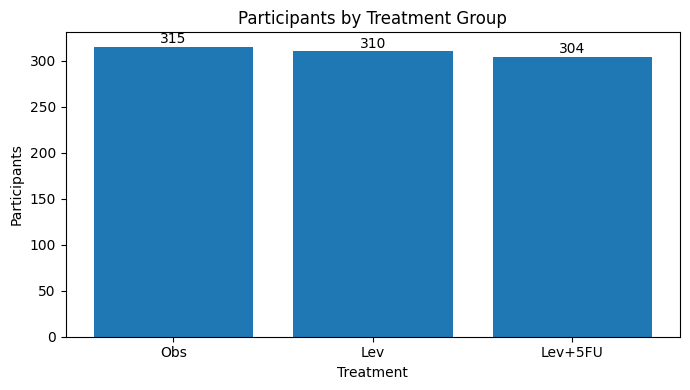

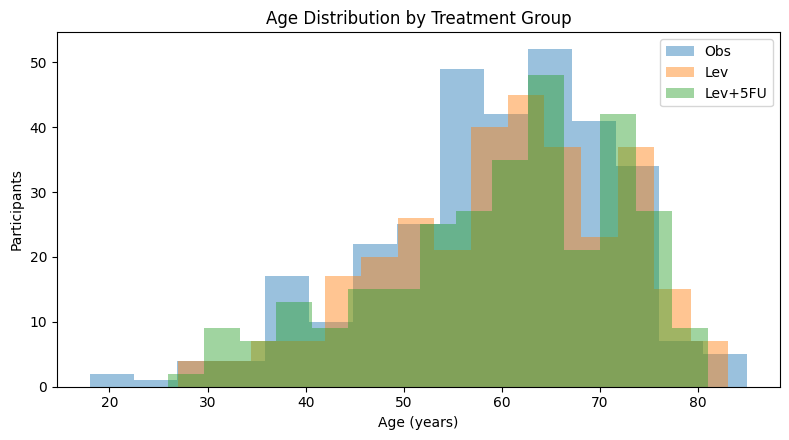

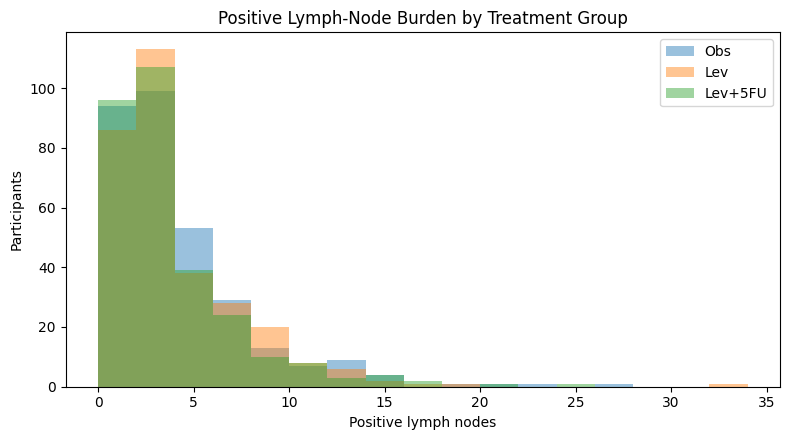

In [7]:
# EDA figure 1: treatment-arm distribution
fig, ax = plt.subplots(figsize=(7,4))
order = ['Obs','Lev','Lev+5FU']
counts = patients['rx'].value_counts().reindex(order)
ax.bar(counts.index, counts.values)
ax.set_title('Participants by Treatment Group')
ax.set_ylabel('Participants')
ax.set_xlabel('Treatment')
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f'{v}', ha='center')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_treatment_arm_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# EDA figure 2: age distribution by treatment
fig, ax = plt.subplots(figsize=(8,4.5))
for arm in order:
    ax.hist(patients.loc[patients['rx'].eq(arm), 'age'], bins=15, alpha=0.45, label=arm)
ax.set_title('Age Distribution by Treatment Group')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Participants')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '02_age_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# EDA figure 3: positive lymph nodes
fig, ax = plt.subplots(figsize=(8,4.5))
for arm in order:
    vals = patients.loc[patients['rx'].eq(arm), 'nodes'].dropna()
    ax.hist(vals, bins=np.arange(0, 35, 2), alpha=0.45, label=arm)
ax.set_title('Positive Lymph-Node Burden by Treatment Group')
ax.set_xlabel('Positive lymph nodes')
ax.set_ylabel('Participants')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_positive_nodes_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

### Simple baseline-balance table

For numeric variables, standardized mean differences (SMDs) compare each active-treatment arm with observation. For binary variables, the standard pooled-proportion SMD is used. SMDs are descriptive—not hypothesis tests.

In [8]:
def smd_continuous(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def smd_binary(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    p1, p0 = a.mean(), b.mean()
    pooled = np.sqrt((p1*(1-p1) + p0*(1-p0)) / 2)
    return (p1 - p0) / pooled if pooled > 0 else np.nan

balance_rows=[]
obs = patients[patients['rx'].eq('Obs')]
for arm in ['Lev','Lev+5FU']:
    trt = patients[patients['rx'].eq(arm)]
    for var in ['age','nodes']:
        balance_rows.append({'comparison':f'{arm} vs Obs','variable':var,'smd':smd_continuous(trt[var],obs[var])})
    for var in ['sex','obstruct','perfor','adhere','surg','node4']:
        balance_rows.append({'comparison':f'{arm} vs Obs','variable':var,'smd':smd_binary(trt[var],obs[var])})
baseline_balance = pd.DataFrame(balance_rows)
display(baseline_balance)

,comparison,variable,smd
0,Lev vs Obs,age,0.0558
1,Lev vs Obs,nodes,-0.0250
2,Lev vs Obs,sex,0.0885
3,Lev vs Obs,obstruct,0.0080
4,Lev vs Obs,perfor,0.0215
5,Lev vs Obs,adhere,0.0246
6,Lev vs Obs,surg,-0.0692
7,Lev vs Obs,node4,0.0242
8,Lev+5FU vs Obs,age,0.0204
9,Lev+5FU vs Obs,nodes,-0.0821


## 7. Kaplan–Meier time-to-event analysis

Two endpoints are analysed directly from the supplied repeated records:

- **Recurrence endpoint (`etype=1`)** — event is recurrence.
- **Overall survival (`etype=2`)** — event is death.

The project dashboard can label the first curve “Recurrence-Free Survival” for consistency with the design, but analytically it is safest to interpret it as the event-free probability for the dataset's supplied recurrence endpoint.

In [9]:
def km_table(data, endpoint_label):
    rows=[]
    for arm in ['Obs','Lev','Lev+5FU']:
        g = data.loc[data['rx'].eq(arm)].sort_values('time')
        sf = SurvfuncRight(g['time'].to_numpy(), g['status'].to_numpy())
        # t=0 anchor for Tableau curves
        rows.append({
            'endpoint':endpoint_label,'treatment_group':arm,'time_days':0,
            'survival_probability':1.0,'ci_lower':1.0,'ci_upper':1.0,
            'n_risk':len(g),'n_events_at_time':0
        })
        for t, s, se, nr, ne in zip(sf.surv_times, sf.surv_prob, sf.surv_prob_se, sf.n_risk, sf.n_events):
            if 0 < s < 1 and se > 0:
                theta = np.log(-np.log(s))
                se_theta = se / (s * abs(np.log(s)))
                lo = np.exp(-np.exp(theta + 1.96 * se_theta))
                hi = np.exp(-np.exp(theta - 1.96 * se_theta))
            else:
                lo, hi = s, s
            rows.append({
                'endpoint':endpoint_label,'treatment_group':arm,'time_days':int(t),
                'survival_probability':float(s),'ci_lower':float(lo),'ci_upper':float(hi),
                'n_risk':int(nr),'n_events_at_time':int(ne)
            })
    return pd.DataFrame(rows)

recurrence_raw = raw.loc[raw['etype'].eq(1)].copy()
death_raw = raw.loc[raw['etype'].eq(2)].copy()

km_recurrence = km_table(recurrence_raw, 'Recurrence-Free Survival')
km_os = km_table(death_raw, 'Overall Survival')
km_curves = pd.concat([km_recurrence, km_os], ignore_index=True)

logrank_rows=[]
for endpoint, d in [('Recurrence-Free Survival', recurrence_raw), ('Overall Survival', death_raw)]:
    stat, p = survdiff(d['time'].to_numpy(), d['status'].to_numpy(), d['rx'].to_numpy())
    logrank_rows.append({'endpoint':endpoint,'logrank_chi_square':float(stat),'p_value':float(p)})
logrank_results = pd.DataFrame(logrank_rows)
display(logrank_results)

,endpoint,logrank_chi_square,p_value
0,Recurrence-Free Survival,23.0617,0.0000
1,Overall Survival,11.6831,0.0029


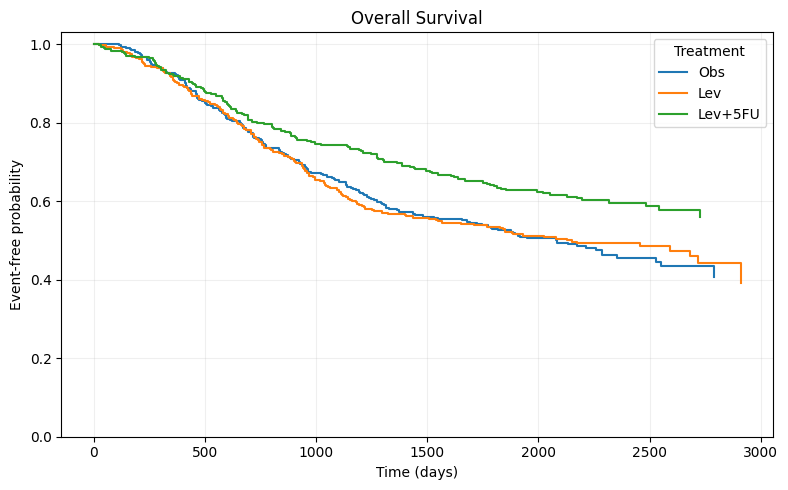

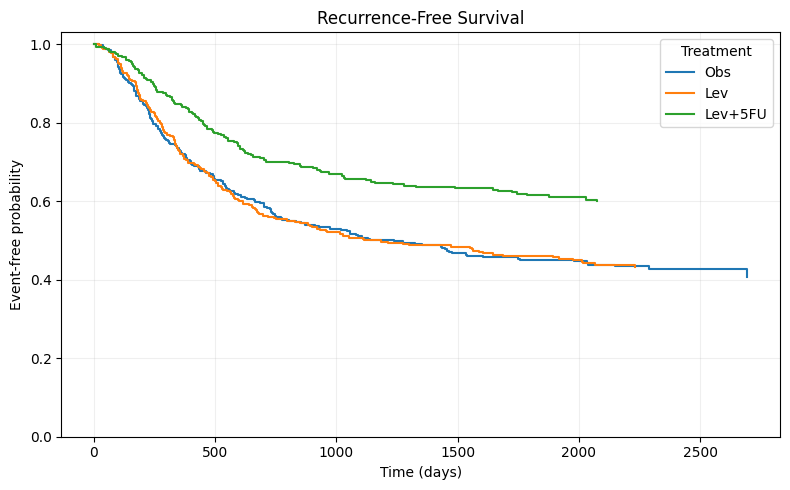

In [10]:
def plot_km(km_df, endpoint, filename):
    fig, ax = plt.subplots(figsize=(8,5))
    for arm in ['Obs','Lev','Lev+5FU']:
        g = km_df[(km_df['endpoint'].eq(endpoint)) & (km_df['treatment_group'].eq(arm))]
        ax.step(g['time_days'], g['survival_probability'], where='post', label=arm)
    ax.set_ylim(0, 1.03)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Event-free probability')
    ax.set_title(endpoint)
    ax.legend(title='Treatment')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()

plot_km(km_curves, 'Overall Survival', '04_overall_survival_km.png')
plot_km(km_curves, 'Recurrence-Free Survival', '05_recurrence_km.png')

## 8. Cox proportional-hazards models

Treatment hazard ratios use **Observation (`Obs`) as the reference group**.

Two specifications are exported:

1. **Unadjusted:** treatment only.
2. **Adjusted:** treatment + age + sex + positive nodes + obstruction + perforation + adherence + surgery-registration timing + tumour differentiation + tumour extent.

The adjusted model uses complete cases for the included covariates. Hazard ratios below 1 indicate a lower estimated hazard relative to the reference group; confidence intervals communicate uncertainty.

In [11]:
def build_cox_matrix(d, adjusted=False):
    d = d.copy()
    d['rx'] = pd.Categorical(d['rx'], categories=['Obs','Lev','Lev+5FU'])
    required = ['time','status','rx']
    if adjusted:
        required += ['age','sex','nodes','obstruct','perfor','adhere','differ','extent','surg']
    d = d[required].dropna().copy()

    X = pd.DataFrame(index=d.index)
    X['Lev vs Obs'] = d['rx'].eq('Lev').astype(float)
    X['Lev+5FU vs Obs'] = d['rx'].eq('Lev+5FU').astype(float)

    if adjusted:
        X['Age per 10 years'] = d['age'].astype(float) / 10
        X['Male'] = d['sex'].astype(float)
        X['Positive nodes'] = d['nodes'].astype(float)
        X['Obstruction'] = d['obstruct'].astype(float)
        X['Perforation'] = d['perfor'].astype(float)
        X['Adherence'] = d['adhere'].astype(float)
        X['Surgery registration long'] = d['surg'].astype(float)
        X['Differ: Well vs Moderate'] = d['differ'].eq(1).astype(float)
        X['Differ: Poor vs Moderate'] = d['differ'].eq(3).astype(float)
        X['Extent: Submucosa vs Serosa'] = d['extent'].eq(1).astype(float)
        X['Extent: Muscle vs Serosa'] = d['extent'].eq(2).astype(float)
        X['Extent: Contiguous vs Serosa'] = d['extent'].eq(4).astype(float)
    return d, X

def fit_cox_endpoint(d, endpoint, adjusted=False):
    work, X = build_cox_matrix(d, adjusted=adjusted)
    model = PHReg(work['time'].astype(float), X.astype(float), status=work['status'].astype(int), ties='efron')
    res = model.fit(disp=0)
    rows=[]
    for name, beta, se in zip(X.columns, res.params, res.bse):
        z = beta / se
        rows.append({
            'endpoint':endpoint,
            'model_type':'Adjusted' if adjusted else 'Unadjusted',
            'term':name,
            'hazard_ratio':float(np.exp(beta)),
            'ci_lower':float(np.exp(beta - 1.96*se)),
            'ci_upper':float(np.exp(beta + 1.96*se)),
            'p_value':float(2*norm.sf(abs(z))),
            'log_hr':float(beta),
            'se_log_hr':float(se),
            'model_n':int(len(work)),
            'model_events':int(work['status'].sum())
        })
    return pd.DataFrame(rows), res, work, X

cox_frames=[]
cox_objects={}
for endpoint, d in [('Recurrence-Free Survival', recurrence_raw), ('Overall Survival', death_raw)]:
    for adjusted in [False, True]:
        out, res, work, X = fit_cox_endpoint(d, endpoint, adjusted=adjusted)
        cox_frames.append(out)
        cox_objects[(endpoint, adjusted)] = (res, work, X)
cox_all = pd.concat(cox_frames, ignore_index=True)

treatment_effects = cox_all[cox_all['term'].isin(['Lev vs Obs','Lev+5FU vs Obs'])].copy()
display(treatment_effects)

,endpoint,model_type,term,hazard_ratio,ci_lower,ci_upper,p_value,log_hr,se_log_hr,model_n,model_events
0,Recurrence-Free Survival,Unadjusted,Lev vs Obs,0.9850,0.7985,1.2150,0.8877,-0.0151,0.1071,929,468
1,Recurrence-Free Survival,Unadjusted,Lev+5FU vs Obs,0.5992,0.4749,0.7561,0.0000,-0.5121,0.1186,929,468
2,Recurrence-Free Survival,Adjusted,Lev vs Obs,0.9341,0.7509,1.1619,0.5403,-0.0682,0.1114,888,446
3,Recurrence-Free Survival,Adjusted,Lev+5FU vs Obs,0.5979,0.4709,0.7593,0.0000,-0.5143,0.1219,888,446
16,Overall Survival,Unadjusted,Lev vs Obs,0.9737,0.7844,1.2087,0.8092,-0.0266,0.1103,929,452
17,Overall Survival,Unadjusted,Lev+5FU vs Obs,0.6896,0.5464,0.8703,0.0017,-0.3717,0.1188,929,452
18,Overall Survival,Adjusted,Lev vs Obs,0.9208,0.7356,1.1527,0.4717,-0.0825,0.1146,888,430
19,Overall Survival,Adjusted,Lev+5FU vs Obs,0.6863,0.5401,0.8720,0.0021,-0.3765,0.1222,888,430


### Proportional-hazards diagnostic

Below is a lightweight exploratory diagnostic based on the Spearman correlation between Schoenfeld residuals and log event time. It is useful as a screening check, but it is **not a replacement** for a full Grambsch–Therneau `cox.zph` analysis.

In [12]:
ph_rows=[]
for (endpoint, adjusted), (res, work, X) in cox_objects.items():
    scho = np.asarray(res.schoenfeld_residuals)
    event_mask = work['status'].to_numpy().astype(bool)
    log_event_time = np.log(work.loc[event_mask, 'time'].to_numpy())
    for j, term in enumerate(X.columns):
        rvals = scho[event_mask, j]
        ok = np.isfinite(rvals) & np.isfinite(log_event_time)
        if ok.sum() >= 5:
            rho, p = spearmanr(rvals[ok], log_event_time[ok])
        else:
            rho, p = np.nan, np.nan
        ph_rows.append({
            'endpoint':endpoint,
            'model_type':'Adjusted' if adjusted else 'Unadjusted',
            'term':term,
            'spearman_rho':rho,
            'p_value':p,
            'diagnostic':'Schoenfeld residual vs log(event time) Spearman correlation'
        })
ph_diagnostics = pd.DataFrame(ph_rows)
display(ph_diagnostics[ph_diagnostics['term'].isin(['Lev vs Obs','Lev+5FU vs Obs'])])

,endpoint,model_type,term,spearman_rho,p_value,diagnostic
0,Recurrence-Free Survival,Unadjusted,Lev vs Obs,0.4569,0.0000,Schoenfeld residual vs log(event time) Spearma...
1,Recurrence-Free Survival,Unadjusted,Lev+5FU vs Obs,-0.5721,0.0000,Schoenfeld residual vs log(event time) Spearma...
2,Recurrence-Free Survival,Adjusted,Lev vs Obs,0.3067,0.0000,Schoenfeld residual vs log(event time) Spearma...
3,Recurrence-Free Survival,Adjusted,Lev+5FU vs Obs,-0.5601,0.0000,Schoenfeld residual vs log(event time) Spearma...
16,Overall Survival,Unadjusted,Lev vs Obs,0.3329,0.0000,Schoenfeld residual vs log(event time) Spearma...
17,Overall Survival,Unadjusted,Lev+5FU vs Obs,-0.5797,0.0000,Schoenfeld residual vs log(event time) Spearma...
18,Overall Survival,Adjusted,Lev vs Obs,0.2538,0.0000,Schoenfeld residual vs log(event time) Spearma...
19,Overall Survival,Adjusted,Lev+5FU vs Obs,-0.5701,0.0000,Schoenfeld residual vs log(event time) Spearma...


## 9. Exploratory subgroup treatment effects

For each subgroup, separate Cox models estimate treatment effects within that subgroup. These are **descriptive/exploratory estimates**, not formal interaction tests. Small subgroup sizes and multiple comparisons can create unstable estimates.

In [13]:
# Merge endpoint data with derived subgroup labels.
subgroup_cols = ['id','age_group','sex_label','nodes_group','differ_label','extent_label']
sg_base = patients[subgroup_cols]
rec_sg = recurrence_raw.merge(sg_base, on='id', how='left', validate='one_to_one')
os_sg = death_raw.merge(sg_base, on='id', how='left', validate='one_to_one')

subgroup_specs = {
    'Age group':'age_group',
    'Sex':'sex_label',
    'Positive lymph nodes':'nodes_group',
    'Tumour differentiation':'differ_label',
    'Tumour extent':'extent_label',
}

def subgroup_cox(d, endpoint):
    out=[]
    for subgroup_name, col in subgroup_specs.items():
        levels = [x for x in d[col].dropna().unique().tolist()]
        for level in levels:
            sub = d[d[col].eq(level)].copy()
            for active in ['Lev','Lev+5FU']:
                two = sub[sub['rx'].isin(['Obs',active])].copy()
                if two['rx'].nunique() < 2 or two['status'].sum() < 5:
                    continue
                X = pd.DataFrame({f'{active} vs Obs': two['rx'].eq(active).astype(float)}, index=two.index)
                try:
                    res = PHReg(two['time'].astype(float), X, status=two['status'].astype(int), ties='efron').fit(disp=0)
                    beta, se = float(res.params[0]), float(res.bse[0])
                    z = beta/se
                    out.append({
                        'endpoint':endpoint,
                        'subgroup':subgroup_name,
                        'subgroup_level':str(level),
                        'comparison':f'{active} vs Obs',
                        'hazard_ratio':float(np.exp(beta)),
                        'ci_lower':float(np.exp(beta-1.96*se)),
                        'ci_upper':float(np.exp(beta+1.96*se)),
                        'p_value_within_subgroup':float(2*norm.sf(abs(z))),
                        'n_total_two_arm':int(len(two)),
                        'events_two_arm':int(two['status'].sum()),
                        'n_obs':int(two['rx'].eq('Obs').sum()),
                        'n_active':int(two['rx'].eq(active).sum()),
                        'exploratory_flag':'Exploratory – no interaction test'
                    })
                except Exception as exc:
                    warnings.warn(f"Could not fit {endpoint}, {subgroup_name}={level}, {active}: {exc}")
    return pd.DataFrame(out)

subgroup_effects = pd.concat([
    subgroup_cox(rec_sg, 'Recurrence-Free Survival'),
    subgroup_cox(os_sg, 'Overall Survival')
], ignore_index=True)

display(subgroup_effects.head(20))

,endpoint,subgroup,subgroup_level,comparison,hazard_ratio,ci_lower,ci_upper,p_value_within_subgroup,n_total_two_arm,events_two_arm,n_obs,n_active,exploratory_flag
0,Recurrence-Free Survival,Age group,<50,Lev vs Obs,0.8151,0.5081,1.3076,0.3966,119,69,60,59,Exploratory – no interaction test
1,Recurrence-Free Survival,Age group,<50,Lev+5FU vs Obs,0.7574,0.4721,1.2152,0.2494,124,69,60,64,Exploratory – no interaction test
2,Recurrence-Free Survival,Age group,50–64,Lev vs Obs,1.0600,0.7662,1.4665,0.7248,268,146,136,132,Exploratory – no interaction test
3,Recurrence-Free Survival,Age group,50–64,Lev+5FU vs Obs,0.5900,0.4033,0.8629,0.0065,252,115,136,116,Exploratory – no interaction test
4,Recurrence-Free Survival,Age group,65+,Lev vs Obs,0.9876,0.7038,1.3857,0.9424,238,134,119,119,Exploratory – no interaction test
5,Recurrence-Free Survival,Age group,65+,Lev+5FU vs Obs,0.5114,0.3498,0.7476,0.0005,243,112,119,124,Exploratory – no interaction test
6,Recurrence-Free Survival,Sex,Male,Lev vs Obs,0.9660,0.7290,1.2802,0.8099,343,194,166,177,Exploratory – no interaction test
7,Recurrence-Free Survival,Sex,Male,Lev+5FU vs Obs,0.4372,0.3065,0.6236,0.0000,307,141,166,141,Exploratory – no interaction test
8,Recurrence-Free Survival,Sex,Female,Lev vs Obs,1.0034,0.7321,1.3753,0.9830,282,155,149,133,Exploratory – no interaction test
9,Recurrence-Free Survival,Sex,Female,Lev+5FU vs Obs,0.7599,0.5544,1.0415,0.0878,312,155,149,163,Exploratory – no interaction test


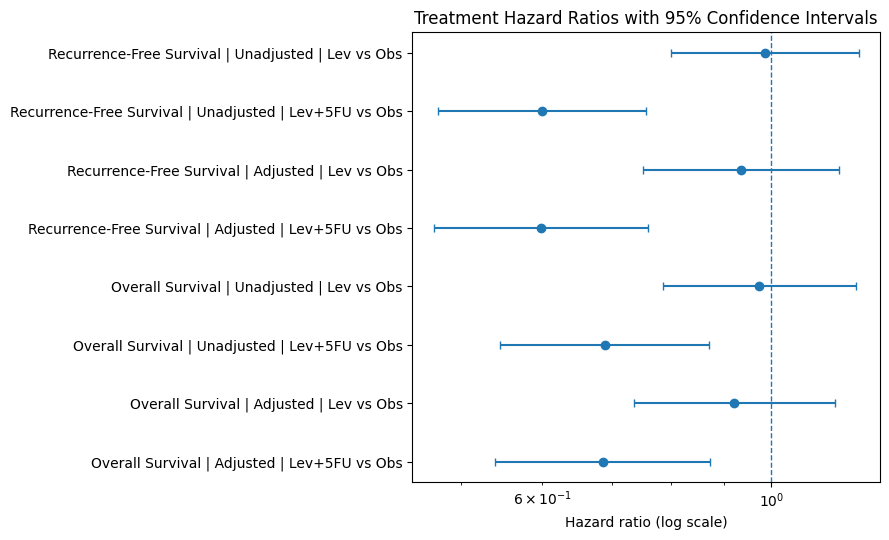

In [14]:
# Forest plot of the primary treatment contrasts (adjusted and unadjusted)
forest = treatment_effects.copy()
forest['label'] = forest['endpoint'] + ' | ' + forest['model_type'] + ' | ' + forest['term']
forest = forest.reset_index(drop=True)

y = np.arange(len(forest))
fig, ax = plt.subplots(figsize=(9,5.5))
ax.errorbar(
    forest['hazard_ratio'], y,
    xerr=[forest['hazard_ratio']-forest['ci_lower'], forest['ci_upper']-forest['hazard_ratio']],
    fmt='o', capsize=3
)
ax.axvline(1, linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(forest['label'])
ax.set_xscale('log')
ax.set_xlabel('Hazard ratio (log scale)')
ax.set_title('Treatment Hazard Ratios with 95% Confidence Intervals')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '06_treatment_hazard_ratio_forest.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Tableau KPI table and exports

The main Tableau source for descriptive worksheets is `01_tableau_patient_level.csv`. Separate long-format files support survival curves, forest plots, subgroup estimates and data quality.

In [15]:
kpi_rows = [
    ('Participants', len(patients), 'count'),
    ('Treatment groups', patients['rx'].nunique(), 'count'),
    ('Follow-up records', len(raw), 'count'),
    ('Recurrence events', int(patients['recurrence_event'].sum()), 'count'),
    ('Deaths', int(patients['death_event'].sum()), 'count'),
    ('Median age', float(patients['age'].median()), 'years'),
    ('Missing positive-node count', int(patients['nodes'].isna().sum()), 'count'),
    ('Missing tumour differentiation', int(patients['differ'].isna().sum()), 'count'),
    ('nodes/node4 inconsistencies', node4_mismatch_n, 'count'),
]
kpi_summary = pd.DataFrame(kpi_rows, columns=['metric','value','unit'])

# Tableau export: event-level source enriched with readable endpoint label.
events_export = raw.copy()
events_export['endpoint'] = events_export['etype'].map({1:'Recurrence-Free Survival',2:'Overall Survival'})
events_export['event_status_label'] = np.where(events_export['status'].eq(1),'Event','Censored')

actions = {
    '01_tableau_patient_level.csv': patients,
    '02_tableau_event_level.csv': events_export,
    '03_tableau_kpi_summary.csv': kpi_summary,
    '04_tableau_missing_data_profile.csv': missing_profile,
    '05_tableau_data_quality_issues.csv': quality_issues,
    '06_tableau_km_curves.csv': km_curves,
    '07_tableau_treatment_hazard_ratios.csv': treatment_effects,
    '08_tableau_subgroup_treatment_effects.csv': subgroup_effects,
    '09_tableau_logrank_tests.csv': logrank_results,
    '10_tableau_ph_diagnostics.csv': ph_diagnostics,
    '11_tableau_baseline_balance.csv': baseline_balance,
    '12_tableau_arm_summary.csv': arm_summary,
}

for filename, frame in actions.items():
    frame.to_csv(EXPORT_DIR / filename, index=False)

mapping = pd.DataFrame([
    [1,'Trial KPI Summary','03_tableau_kpi_summary.csv'],
    [2,'Treatment-Arm Distribution','01_tableau_patient_level.csv'],
    [3,'Age Distribution','01_tableau_patient_level.csv'],
    [4,'Missing-Data Profile','04_tableau_missing_data_profile.csv'],
    [5,'Sex by Treatment Group','01_tableau_patient_level.csv'],
    [6,'Tumour Differentiation','01_tableau_patient_level.csv'],
    [7,'Tumour Extent','01_tableau_patient_level.csv'],
    [8,'Positive Lymph Nodes','01_tableau_patient_level.csv'],
    [9,'Overall-Survival Curve','06_tableau_km_curves.csv'],
    [10,'Recurrence-Free Survival Curve','06_tableau_km_curves.csv'],
    [11,'Treatment Hazard Ratios','07_tableau_treatment_hazard_ratios.csv'],
    [12,'Subgroup Treatment Effects','08_tableau_subgroup_treatment_effects.csv'],
], columns=['sheet_number','worksheet','recommended_source_file'])
mapping.to_csv(EXPORT_DIR / '00_tableau_worksheet_mapping.csv', index=False)

print('Exported files:')
for p in sorted(EXPORT_DIR.glob('*.csv')):
    print(' -', p.name)

Exported files:
 - 00_tableau_worksheet_mapping.csv
 - 01_tableau_patient_level.csv
 - 02_tableau_event_level.csv
 - 03_tableau_kpi_summary.csv
 - 04_tableau_missing_data_profile.csv
 - 05_tableau_data_quality_issues.csv
 - 06_tableau_km_curves.csv
 - 07_tableau_treatment_hazard_ratios.csv
 - 08_tableau_subgroup_treatment_effects.csv
 - 09_tableau_logrank_tests.csv
 - 10_tableau_ph_diagnostics.csv
 - 11_tableau_baseline_balance.csv
 - 12_tableau_arm_summary.csv


## 11. Final verification

This cell re-reads the exported CSV files and confirms that the main files are non-empty and that the patient export remains one row per participant.

In [16]:
verification=[]
for path in sorted(EXPORT_DIR.glob('*.csv')):
    frame = pd.read_csv(path)
    verification.append({'file':path.name,'rows':len(frame),'columns':frame.shape[1]})
verification = pd.DataFrame(verification)

display(verification)

assert pd.read_csv(EXPORT_DIR/'01_tableau_patient_level.csv')['id'].nunique() == len(patients)
assert len(pd.read_csv(EXPORT_DIR/'01_tableau_patient_level.csv')) == len(patients)
assert set(pd.read_csv(EXPORT_DIR/'06_tableau_km_curves.csv')['endpoint']) == {'Recurrence-Free Survival','Overall Survival'}
assert not pd.read_csv(EXPORT_DIR/'07_tableau_treatment_hazard_ratios.csv').empty
assert not pd.read_csv(EXPORT_DIR/'08_tableau_subgroup_treatment_effects.csv').empty

print('All export checks passed.')

,file,rows,columns
0,00_tableau_worksheet_mapping.csv,12,3
1,01_tableau_patient_level.csv,929,30
2,02_tableau_event_level.csv,1858,19
3,03_tableau_kpi_summary.csv,9,3
4,04_tableau_missing_data_profile.csv,40,7
5,05_tableau_data_quality_issues.csv,3,5
6,06_tableau_km_curves.csv,879,8
7,07_tableau_treatment_hazard_ratios.csv,8,11
8,08_tableau_subgroup_treatment_effects.csv,58,13
9,09_tableau_logrank_tests.csv,2,3


All export checks passed.


## Tableau build notes

- Use `01_tableau_patient_level.csv` as the main source for descriptive sheets 2–3 and 5–8.
- Use `04_tableau_missing_data_profile.csv` for the missingness heatmap/bar chart.
- Use `06_tableau_km_curves.csv` for sheets 9–10. Put `time_days` on Columns, `survival_probability` on Rows, and `treatment_group` on Colour; filter by `endpoint`.
- Use `07_tableau_treatment_hazard_ratios.csv` for the treatment forest plot. A log axis is recommended because hazard ratios are multiplicative.
- Use `08_tableau_subgroup_treatment_effects.csv` for the subgroup forest plot. Add filters for endpoint and treatment comparison.
- Keep the caveat **“Exploratory – no interaction test”** visible on the subgroup dashboard.
- The `node4` source field is retained, and its inconsistency with `nodes > 4` is intentionally disclosed rather than silently corrected.